# Single Neuron Parameters



# Set Parameters:

# 6 neuron experiments





Mar 05 19:53:22 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 05 19:53:22 NodeManager::prepare_nodes [Info]: 
    Preparing 26 nodes for simulation.

Mar 05 19:53:22 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 26
    Simulation time (ms): 2000
    Number of OpenMP threads: 1
    Not using MPI

Mar 05 19:53:27 SimulationManager::run [Info]: 
    Simulation finished.


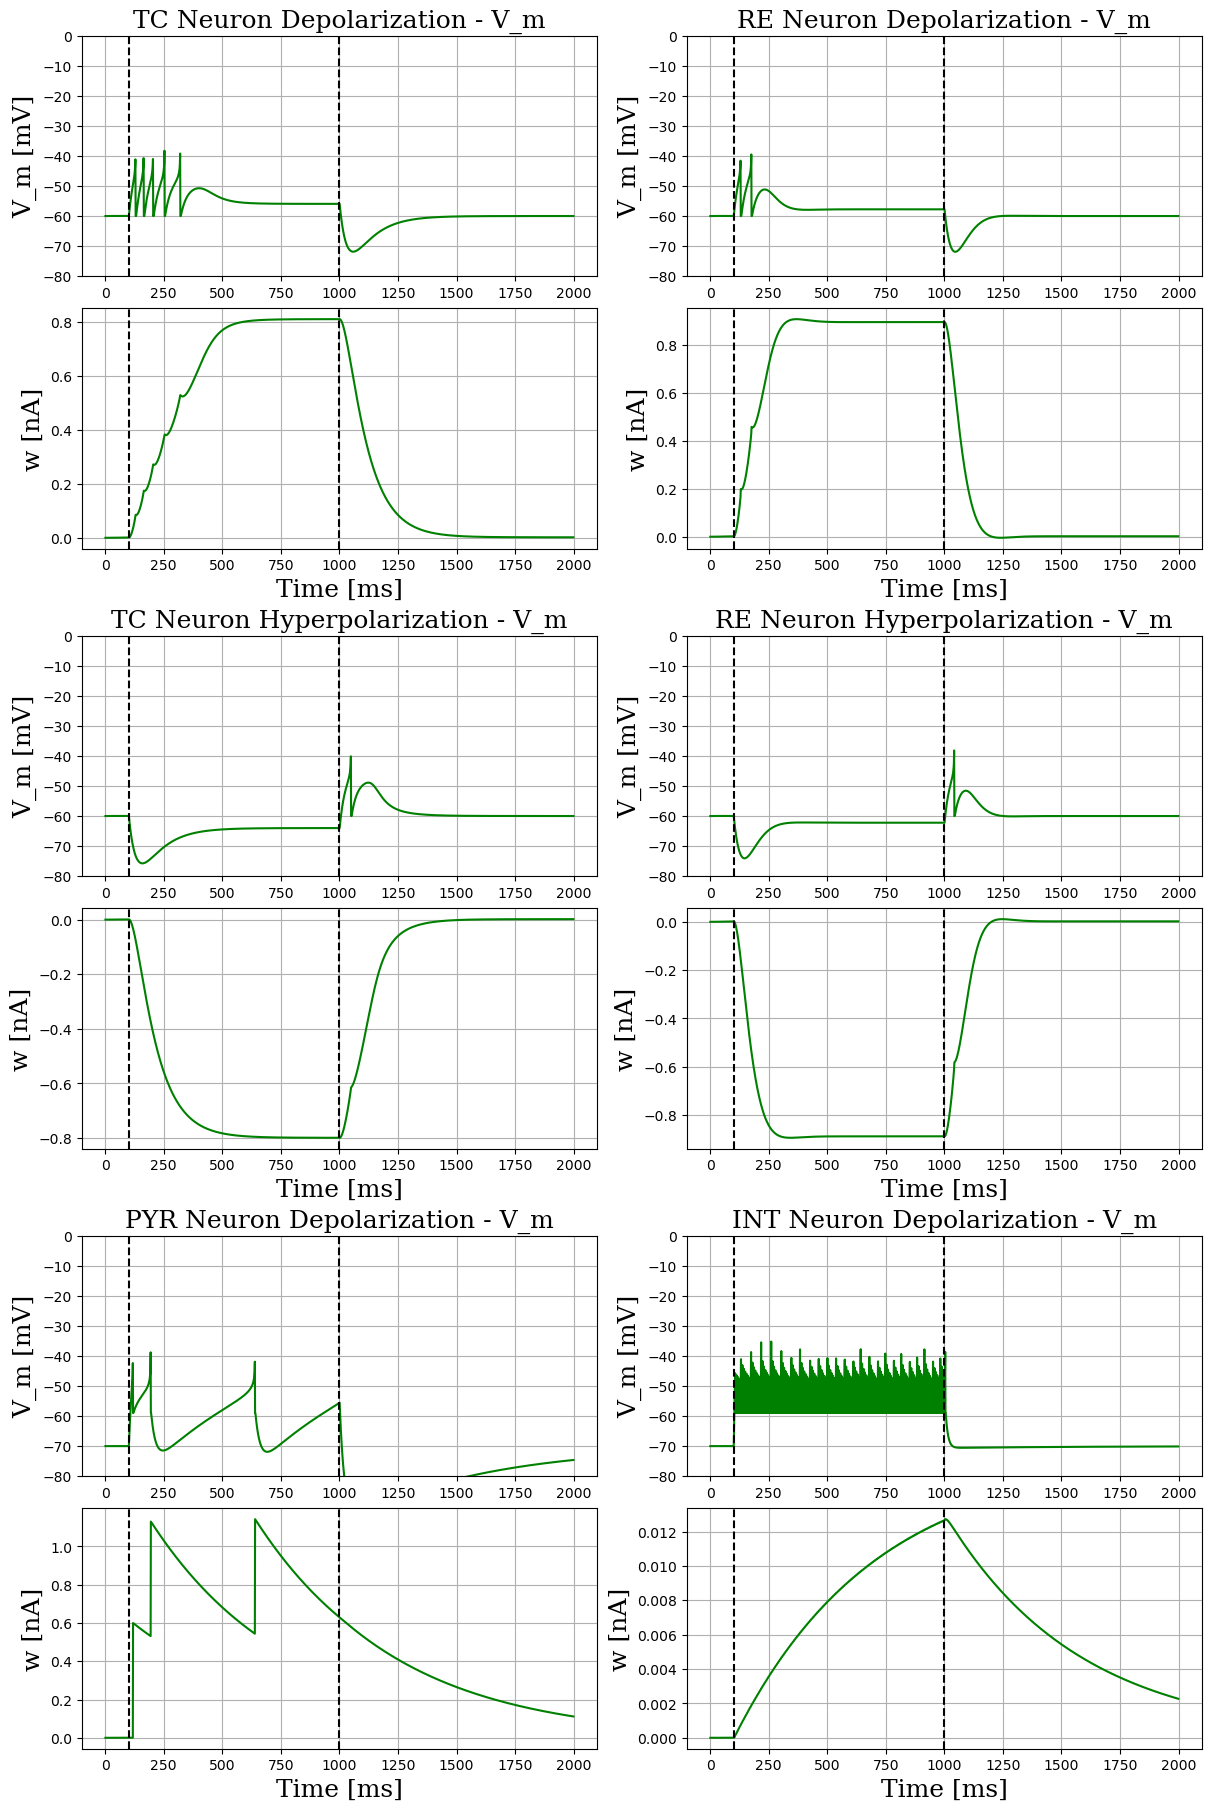

# FI Curve PYR

[   0.  200.  400.  600.  800. 1000. 1200. 1400.]


In [55]:
data_PY = pulse_curves(neuron_dicts["PY"], input_strength)
data_INT = pulse_curves(neuron_dicts["INT"], input_strength)
data_TC = pulse_curves(neuron_dicts["TC"], input_strength)
data_RE = pulse_curves(neuron_dicts["RE"], input_strength)


Mar 05 21:34:16 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 05 21:34:16 NodeManager::prepare_nodes [Info]: 
    Preparing 5 nodes for simulation.

Mar 05 21:34:16 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 5
    Simulation time (ms): 2000
    Number of OpenMP threads: 1
    Not using MPI

Mar 05 21:34:17 SimulationManager::run [Info]: 
    Simulation finished.

Mar 05 21:34:17 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 05 21:34:17 NodeManager::prepare_nodes [Info]: 
    Preparing 5 nodes for simulation.

Mar 05 21:34:17 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 5
    Simulation time (ms): 2000
    Number of OpenMP threads: 1
    Not using MPI

Mar 05 21:34:19 SimulationManager::run [Info]: 
    Simulation finished.

Mar 05 21:34:19 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms

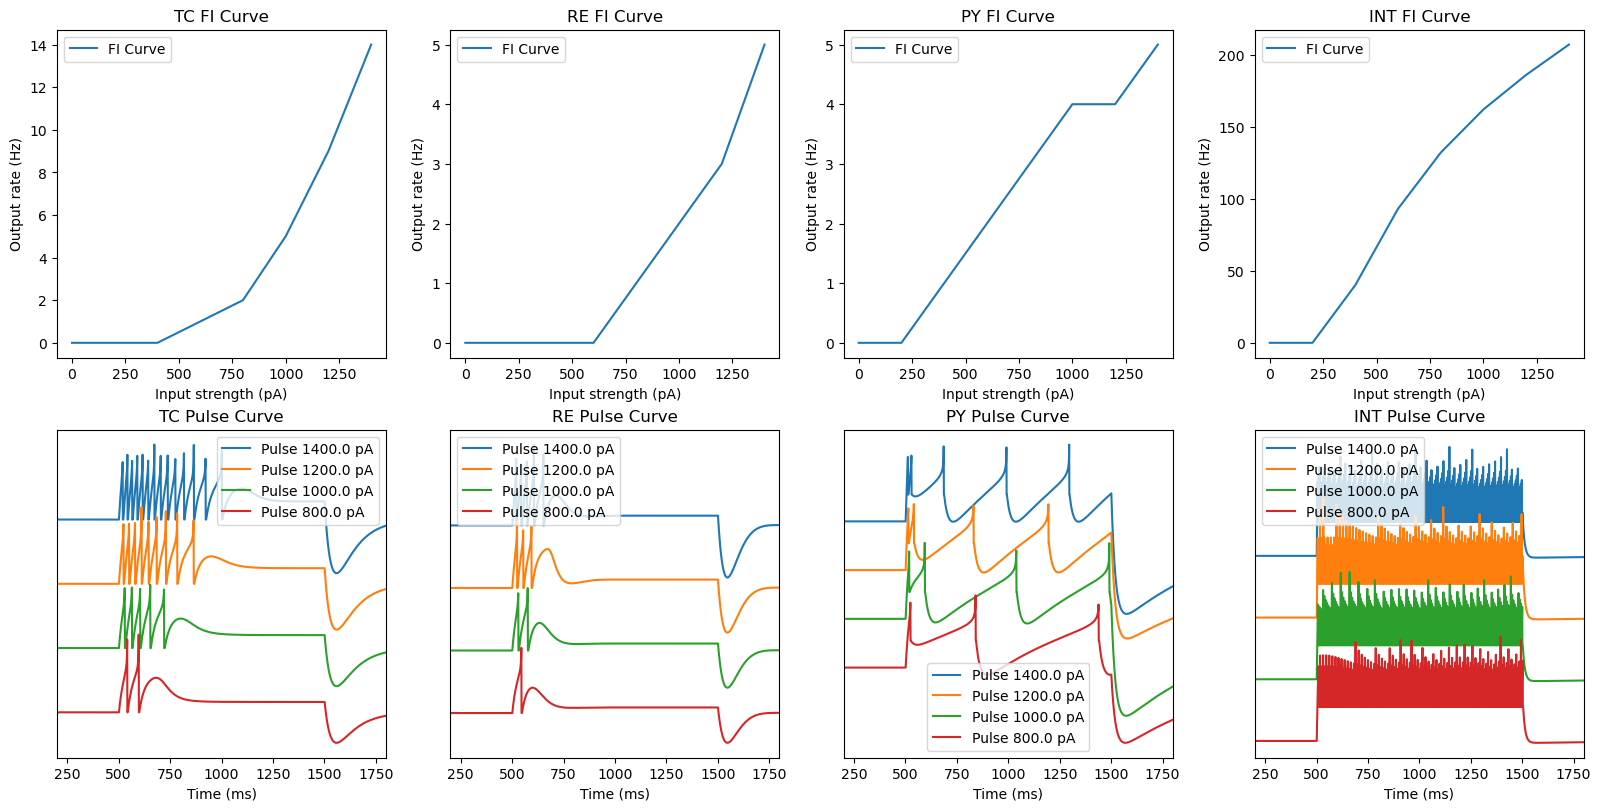

In [64]:
#create a plot for each neuron type with its pulse curves and FI curve
neuron_types=["TC","RE","PY","INT"]
pulse_curves_TC=[data_TC[0],data_TC[1]]
pulse_curves_RE=[data_RE[0],data_RE[1]]
pulse_curves_PY=[data_PY[0],data_PY[1]]
pulse_curves_INT=[data_INT[0],data_INT[1]]
pulse_curves=[pulse_curves_TC,pulse_curves_RE,pulse_curves_PY,pulse_curves_INT]

output_rates_PY=[len(data_PY[2][i]) for i in range(len(data_PY[2]))]
output_rates_INT=[len(data_INT[2][i]) for i in range(len(data_INT[2]))]
output_rates_TC=[len(data_TC[2][i]) for i in range(len(data_TC[2]))]
output_rates_RE=[len(data_RE[2][i]) for i in range(len(data_RE[2]))]

FI_curves=[output_rates_TC,output_rates_RE,output_rates_PY,output_rates_INT]


fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8), constrained_layout=True)
for i in range(4):
    ax1 = axes[0, i]
    ax2 = axes[1, i]
    
    # Plot FI curves
    ax1.plot(input_strength, FI_curves[i], label='FI Curve')
    ax1.set_title(f'{neuron_types[i]} FI Curve')
    ax1.set_xlabel("Input strength (pA)")
    ax1.set_ylabel("Output rate (Hz)")
    ax1.legend()
    # Plot pulse curves
    for k in range(len(input_strength) - 1, 3, -1):
        ax2.plot(pulse_curves[i][1][k], pulse_curves[i][0][k] + (k * 20), label=f'Pulse {input_strength[k]} pA')
    ax2.set_title(f'{neuron_types[i]} Pulse Curve')
    ax2.set_xlabel("Time (ms)")
    ax2.set_ylabel("Membrane potential (mV)")
    ax2.set_xlim(200, 1800)
    ax2.legend(fontsize='x-small')
    ax2.yaxis.set_visible(False)
    ax2.legend()



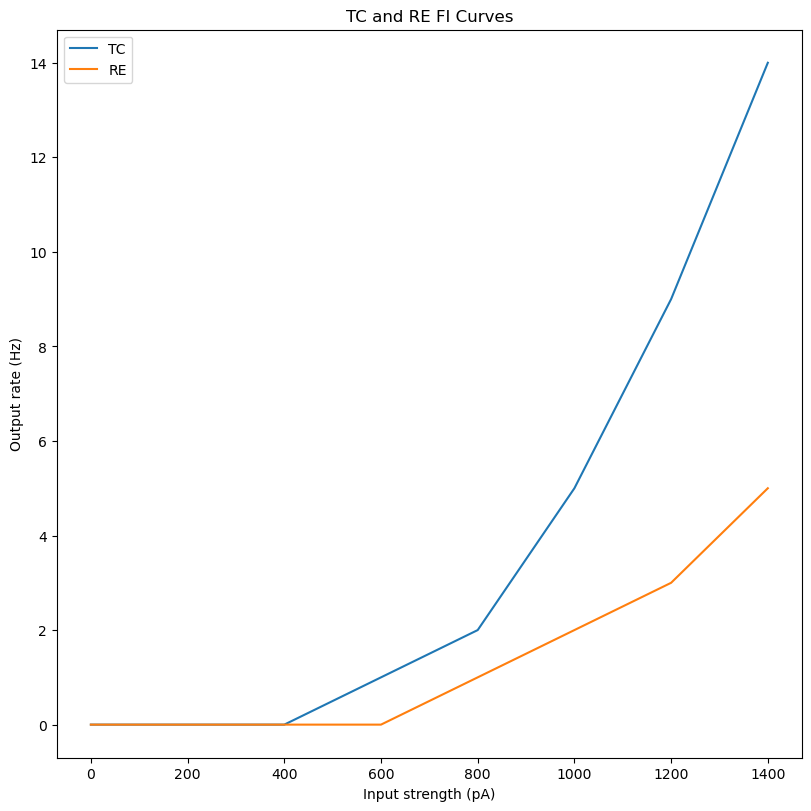

In [60]:
#make a plot of TC and RE neurons overlapping 

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
ax.plot(input_strength, output_rates_TC, label='TC')
ax.plot(input_strength, output_rates_RE, label='RE')
ax.set_title('TC and RE FI Curves')
ax.set_xlabel("Input strength (pA)")
ax.set_ylabel("Output rate (Hz)")
ax.legend()
plt.show()
